# Prova 02 — Paradigmas de Aprendizagem de Máquina
## Questão 4 — Aprendizado Não Supervisionado

**Aluno:** Jorge Alberto Macedo Costa de Oliveira  
**Dataset:** Diabetes 130-US Hospitals (1999–2008)  
**Link:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---
**Objetivo:**
- Aplicar K-means com o método do cotovelo para determinar o melhor K
- Executar clusterização hierárquica com dois métodos de linkage (Ward e Complete)
- Comparar visualmente os resultados obtidos pelos diferentes métodos

## 4.0 — Imports e Configurações

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram
from kneed import KneeLocator

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

print('Configurações inicializadas com sucesso!')

Configurações inicializadas com sucesso!


## 4.1 — Carga dos Dados

Carregamos os dados já pré-processados da Questão 1 (Top-30 features selecionadas por importância).

Conforme o enunciado, removemos o **rótulo da classe** (`readmitted`) para trabalhar com aprendizado não supervisionado.

In [2]:
# Carregar dados pré-processados
data_path = 'data/diabetes_preprocessed_topk.csv'
df = pd.read_csv(data_path)

print(f'Dados carregados: {df.shape}')
print(f'Colunas: {df.columns.tolist()}')

# Remover o rótulo da classe (aprendizado não supervisionado)
X = df.drop('readmitted', axis=1)

print(f'\nFeatures (sem rótulo): {X.shape}')
print(f'\nEstatísticas descritivas:')
X.describe().round(2)

Dados carregados: (101763, 31)
Colunas: ['number_inpatient', 'discharge_disposition_id_11', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'num_medications', 'admission_source_id_7', 'num_lab_procedures', 'age', 'num_procedures', 'time_in_hospital', 'admission_source_id_6', 'discharge_disposition_id_6', 'diabetesMed_Yes', 'admission_source_id_4', 'discharge_disposition_id_14', 'admission_type_id_3', 'admission_type_id_6', 'insulin', 'discharge_disposition_id_22', 'diag_1_cat_Neoplasias', 'diag_1_cat_Diabetes', 'discharge_disposition_id_13', 'change_No', 'metformin', 'medical_specialty_Unknown', 'A1Cresult', 'discharge_disposition_id_3', 'max_glu_serum', 'diag_1_cat_Gravidez', 'readmitted']

Features (sem rótulo): (101763, 30)

Estatísticas descritivas:


,number_inpatient,discharge_disposition_id_11,number_emergency,number_diagnoses,number_outpatient,num_medications,admission_source_id_7,num_lab_procedures,age,num_procedures,...,diag_1_cat_Neoplasias,diag_1_cat_Diabetes,discharge_disposition_id_13,change_No,metformin,medical_specialty_Unknown,A1Cresult,discharge_disposition_id_3,max_glu_serum,diag_1_cat_Gravidez
count,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,...,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00,101763.00
mean,0.64,0.02,0.20,7.42,0.37,16.02,0.56,43.10,6.10,1.34,...,0.03,0.09,0.00,0.54,0.40,0.49,0.37,0.14,0.09,0.01
std,1.26,0.13,0.93,1.93,1.27,8.13,0.50,19.67,1.59,1.71,...,0.18,0.28,0.06,0.50,0.81,0.50,0.89,0.34,0.43,0.08
min,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,6.00,0.00,10.00,0.00,31.00,5.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,0.00,0.00,0.00,8.00,0.00,15.00,1.00,44.00,6.00,1.00,...,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,1.00,0.00,0.00,9.00,0.00,20.00,1.00,57.00,7.00,2.00,...,0.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00
max,21.00,1.00,76.00,16.00,42.00,81.00,1.00,132.00,9.00,6.00,...,1.00,1.00,1.00,1.00,3.00,1.00,3.00,1.00,3.00,1.00


## 4.2 — Normalização dos Dados

Antes de aplicar os algoritmos de clusterização, é fundamental **normalizar os dados** com `StandardScaler`.

**Justificativa:** O K-means calcula distâncias euclidianas entre os pontos. Sem normalização, features com escalas maiores dominariam o cálculo de distância, distorcendo os clusters. A normalização garante que todas as features contribuam igualmente.

In [3]:
# Normalizar os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Shape dos dados normalizados: {X_scaled.shape}')
print(f'\nMédia das features (após normalização): {X_scaled.mean(axis=0).mean():.6f}')
print(f'Desvio padrão das features (após normalização): {X_scaled.std(axis=0).mean():.6f}')

# Verificar que a normalização funcionou
print(f'\nMin: {X_scaled.min():.4f}')
print(f'Max: {X_scaled.max():.4f}')

Shape dos dados normalizados: (101763, 30)

Média das features (após normalização): 0.000000
Desvio padrão das features (após normalização): 1.000000

Min: -3.8245
Max: 81.4656


## 4.3 — K-Means: Método do Cotovelo

O **método do cotovelo** (Elbow Method) consiste em:
1. Treinar o K-means para diferentes valores de K
2. Calcular a **inércia** (soma das distâncias quadráticas intra-cluster) para cada K
3. Plotar a curva e identificar o ponto de "cotovelo" — onde a redução marginal da inércia diminui significativamente

Testamos K variando de **2 a 12**.

Para identificar o cotovelo automaticamente, utilizamos a biblioteca `kneed` (KneeLocator), que detecta o ponto de curvatura máxima na curva de inércia.

In [4]:
print('=== MÉTODO DO COTOVELO ===')
print('Calculando inércia para diferentes valores de K...\n')

# Range de valores de K
K_range = range(2, 13)
inertias = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f'K = {k:2d} | Inércia = {kmeans.inertia_:,.2f}')

print('\nCálculo concluído!')

=== MÉTODO DO COTOVELO ===
Calculando inércia para diferentes valores de K...



K =  2 | Inércia = 2,876,025.85


K =  3 | Inércia = 2,758,760.61


K =  4 | Inércia = 2,656,846.07


K =  5 | Inércia = 2,560,051.20


...

K =  8 | Inércia = 2,298,445.77


K =  9 | Inércia = 2,184,689.97


K = 10 | Inércia = 2,111,383.10


K = 11 | Inércia = 2,009,869.03


K = 12 | Inércia = 1,940,608.18

Cálculo concluído!


Cotovelo detectado pelo KneeLocator: K = 3


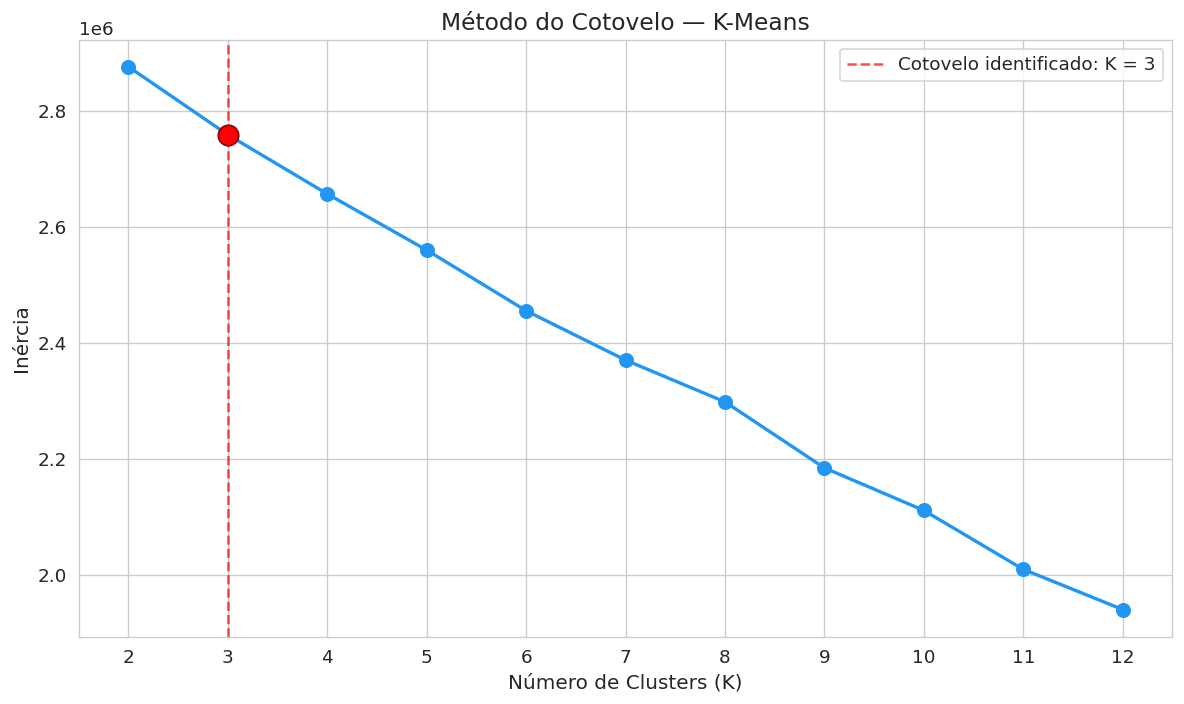


>>> K sugerido pelo método do cotovelo: 3


In [5]:
# Identificar o cotovelo automaticamente com KneeLocator
kl = KneeLocator(list(K_range), inertias, curve='convex', direction='decreasing')
best_k = kl.elbow if kl.elbow is not None else 3  # fallback para K=3
best_k_idx = list(K_range).index(best_k)

print(f'Cotovelo detectado pelo KneeLocator: K = {best_k}')

# Gráfico do método do cotovelo
plt.figure(figsize=(10, 6))

plt.plot(list(K_range), inertias, 'o-', color='#2196F3', linewidth=2, markersize=8)

plt.axvline(x=best_k, color='red', linestyle='--', linewidth=1.5, alpha=0.7,
            label=f'Cotovelo identificado: K = {best_k}')
plt.scatter([best_k], [inertias[best_k_idx]], color='red', s=150, zorder=5, edgecolors='darkred')

plt.xlabel('Número de Clusters (K)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo — K-Means', fontsize=14)
plt.xticks(list(K_range))
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f'\n>>> K sugerido pelo método do cotovelo: {best_k}')

## 4.4 — Treinamento do K-Means Final

Com o valor de K identificado pelo método do cotovelo, treinamos o modelo K-means final e analisamos os clusters resultantes.

In [6]:
print(f'=== K-MEANS FINAL (K = {best_k}) ===')

# Treinar K-means com o K escolhido
kmeans_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10, max_iter=300)
labels_kmeans = kmeans_final.fit_predict(X_scaled)

print(f'\nInércia final: {kmeans_final.inertia_:,.2f}')
print(f'Número de iterações: {kmeans_final.n_iter_}')

# Distribuição dos clusters
print(f'\nDistribuição dos clusters K-Means:')
unique, counts = np.unique(labels_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    pct = count / len(labels_kmeans) * 100
    print(f'  Cluster {cluster}: {count:,} amostras ({pct:.1f}%)')

=== K-MEANS FINAL (K = 3) ===



Inércia final: 2,758,760.61
Número de iterações: 18

Distribuição dos clusters K-Means:
  Cluster 0: 35,446 amostras (34.8%)
  Cluster 1: 20,957 amostras (20.6%)
  Cluster 2: 45,360 amostras (44.6%)


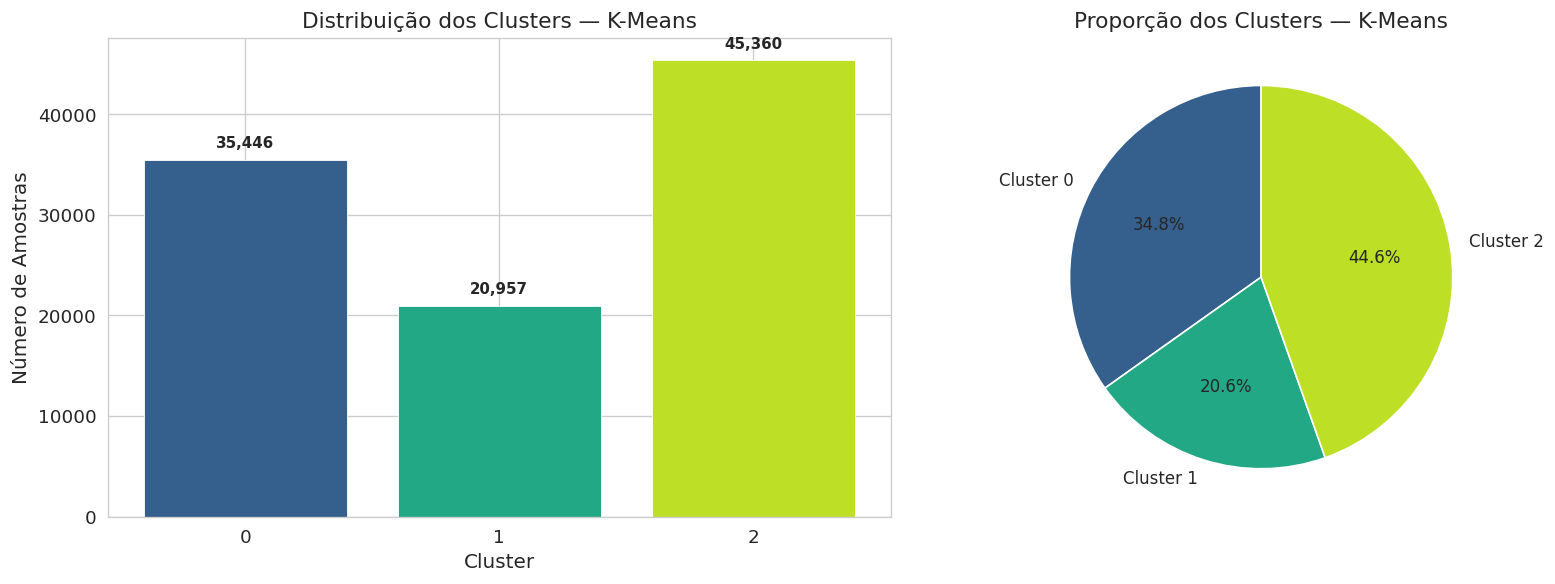

In [7]:
# Gráfico de distribuição dos clusters K-Means
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
colors = plt.cm.viridis(np.linspace(0.3, 0.9, best_k))
axes[0].bar(unique, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Cluster', fontsize=12)
axes[0].set_ylabel('Número de Amostras', fontsize=12)
axes[0].set_title('Distribuição dos Clusters — K-Means', fontsize=13)
axes[0].set_xticks(unique)

# Adicionar valores sobre as barras
for i, (cluster, count) in enumerate(zip(unique, counts)):
    axes[0].text(cluster, count + max(counts) * 0.02, f'{count:,}',
                ha='center', va='bottom', fontweight='bold', fontsize=9)

# Gráfico de pizza
axes[1].pie(counts, labels=[f'Cluster {c}' for c in unique], autopct='%1.1f%%',
           colors=colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporção dos Clusters — K-Means', fontsize=13)

plt.tight_layout()
plt.show()

In [8]:
# Análise dos centroides
print('=== ANÁLISE DOS CENTROIDES ===')
print('Valores médios das features mais relevantes por cluster:\n')

# Criar DataFrame com centroides (escala original para interpretabilidade)
centroids_original = scaler.inverse_transform(kmeans_final.cluster_centers_)
df_centroids = pd.DataFrame(centroids_original, columns=X.columns)
df_centroids.index.name = 'Cluster'

# Selecionar as top-10 features mais importantes (baseado na Questão 3)
top_features = ['number_inpatient', 'num_lab_procedures', 'num_medications',
                'time_in_hospital', 'number_diagnoses', 'age',
                'num_procedures', 'number_emergency', 'number_outpatient',
                'discharge_disposition_id_11']

# Filtrar apenas as features que existem no dataset
top_features = [f for f in top_features if f in df_centroids.columns]

print(df_centroids[top_features].round(3).to_string())

=== ANÁLISE DOS CENTROIDES ===
Valores médios das features mais relevantes por cluster:

         number_inpatient  num_lab_procedures  num_medications  time_in_hospital  number_diagnoses    age  num_procedures  number_emergency  number_outpatient  discharge_disposition_id_11
Cluster                                                                                                                                                                                    
0                   0.554              41.695           12.326             3.713             7.260  6.294           0.995             0.147              0.340                        0.023
1                   0.474              34.538           18.732             4.388             7.051  5.953           2.253             0.094              0.277                        0.007
2                   0.774              48.166           17.675             4.938             7.723  6.008           1.188             0.286              0.435 

## 4.5 — Clusterização Hierárquica

### Consideração sobre o Tamanho do Dataset

A clusterização hierárquica aglomerativa possui complexidade **O(n²) em memória** e **O(n³) em tempo**. Com ~101.763 amostras, a matriz de distâncias exigiria aproximadamente **77 GB de RAM**, o que é computacionalmente inviável.

**Solução adotada:** Utilizamos uma **amostra aleatória** de **5.000 registros** para a clusterização hierárquica. Essa abordagem é comum em projetos acadêmicos e na literatura quando o dataset é muito grande para algoritmos com complexidade quadrática.

A amostra é suficientemente grande para produzir resultados representativos e permitir a geração de **dendrogramas** informativos.

### Métodos de Linkage

Utilizamos dois métodos de linkage conforme solicitado:

1. **Ward:** Minimiza a **variância total intra-cluster** a cada fusão. Tende a produzir clusters compactos e de tamanhos similares.
2. **Complete (Ligação Completa):** Utiliza a **distância máxima** entre pontos de dois clusters. Mais robusto a outliers e tende a produzir clusters mais compactos.

In [9]:
print('=== PREPARAÇÃO DA AMOSTRA PARA CLUSTERIZAÇÃO HIERÁRQUICA ===')

# Tamanho da amostra
SAMPLE_SIZE = 5000

# Amostragem aleatória
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(X_scaled), size=SAMPLE_SIZE, replace=False)
X_sample = X_scaled[sample_indices]

print(f'Tamanho do dataset original: {len(X_scaled):,}')
print(f'Tamanho da amostra: {len(X_sample):,}')
print(f'Proporção utilizada: {len(X_sample) / len(X_scaled) * 100:.1f}%')

=== PREPARAÇÃO DA AMOSTRA PARA CLUSTERIZAÇÃO HIERÁRQUICA ===
Tamanho do dataset original: 101,763
Tamanho da amostra: 5,000
Proporção utilizada: 4.9%


### 4.5.1 — Dendrogramas

Plotamos os dendrogramas truncados para cada método de linkage, permitindo visualizar a estrutura hierárquica dos clusters.

In [10]:
print('=== DENDROGRAMAS ===')
print('Calculando linkage Ward...\n')

# Calcular linkage para ambos os métodos
linkage_ward = linkage(X_sample, method='ward', metric='euclidean')
print('Linkage Ward concluído!')

print('Calculando linkage Complete...')
linkage_complete = linkage(X_sample, method='complete', metric='euclidean')
print('Linkage Complete concluído!')

=== DENDROGRAMAS ===
Calculando linkage Ward...



Linkage Ward concluído!
Calculando linkage Complete...


Linkage Complete concluído!


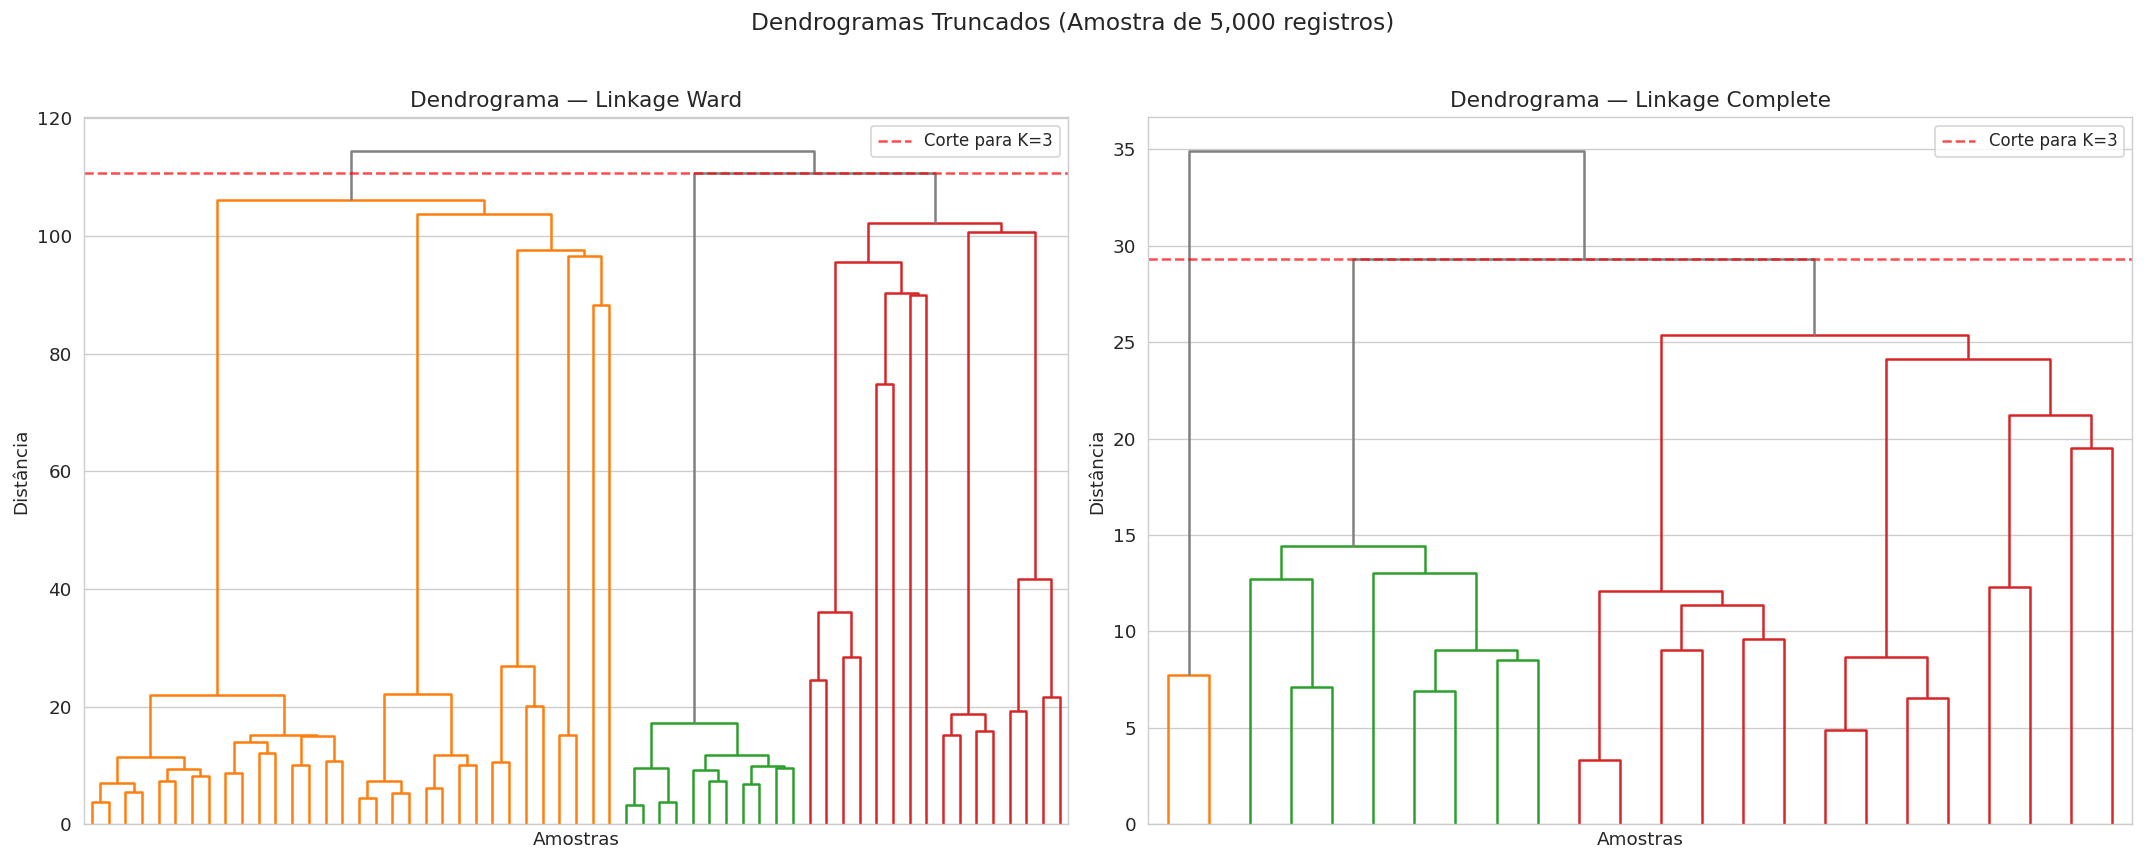

In [11]:
# Plotar dendrogramas lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Dendrograma Ward
dendrogram(
    linkage_ward,
    ax=axes[0],
    truncate_mode='level',
    p=5,
    color_threshold=linkage_ward[-(best_k - 1), 2],
    no_labels=True,
    above_threshold_color='gray'
)
axes[0].set_title('Dendrograma — Linkage Ward', fontsize=13)
axes[0].set_xlabel('Amostras', fontsize=11)
axes[0].set_ylabel('Distância', fontsize=11)
axes[0].axhline(y=linkage_ward[-(best_k - 1), 2], color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Corte para K={best_k}')
axes[0].legend(fontsize=10)

# Dendrograma Complete
dendrogram(
    linkage_complete,
    ax=axes[1],
    truncate_mode='level',
    p=5,
    color_threshold=linkage_complete[-(best_k - 1), 2],
    no_labels=True,
    above_threshold_color='gray'
)
axes[1].set_title('Dendrograma — Linkage Complete', fontsize=13)
axes[1].set_xlabel('Amostras', fontsize=11)
axes[1].set_ylabel('Distância', fontsize=11)
axes[1].axhline(y=linkage_complete[-(best_k - 1), 2], color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label=f'Corte para K={best_k}')
axes[1].legend(fontsize=10)

plt.suptitle(f'Dendrogramas Truncados (Amostra de {SAMPLE_SIZE:,} registros)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.5.2 — Clusterização Hierárquica com K clusters

In [12]:
print(f'=== CLUSTERIZAÇÃO HIERÁRQUICA (K = {best_k}) ===')

# Linkage Ward
print(f'\n--- Linkage Ward ---')
hc_ward = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
labels_ward = hc_ward.fit_predict(X_sample)

unique_w, counts_w = np.unique(labels_ward, return_counts=True)
print('Distribuição dos clusters (Ward):')
for cluster, count in zip(unique_w, counts_w):
    pct = count / len(labels_ward) * 100
    print(f'  Cluster {cluster}: {count:,} amostras ({pct:.1f}%)')

# Linkage Complete
print(f'\n--- Linkage Complete ---')
hc_complete = AgglomerativeClustering(n_clusters=best_k, linkage='complete')
labels_complete = hc_complete.fit_predict(X_sample)

unique_c, counts_c = np.unique(labels_complete, return_counts=True)
print('Distribuição dos clusters (Complete):')
for cluster, count in zip(unique_c, counts_c):
    pct = count / len(labels_complete) * 100
    print(f'  Cluster {cluster}: {count:,} amostras ({pct:.1f}%)')

=== CLUSTERIZAÇÃO HIERÁRQUICA (K = 3) ===

--- Linkage Ward ---


Distribuição dos clusters (Ward):
  Cluster 0: 1,043 amostras (20.9%)
  Cluster 1: 3,935 amostras (78.7%)
  Cluster 2: 22 amostras (0.4%)

--- Linkage Complete ---


Distribuição dos clusters (Complete):
  Cluster 0: 4,987 amostras (99.7%)
  Cluster 1: 2 amostras (0.0%)
  Cluster 2: 11 amostras (0.2%)


## 4.6 — Comparação Visual dos Resultados

Comparamos a distribuição dos clusters obtidos pelos três métodos: K-Means, Hierárquica Ward e Hierárquica Complete.

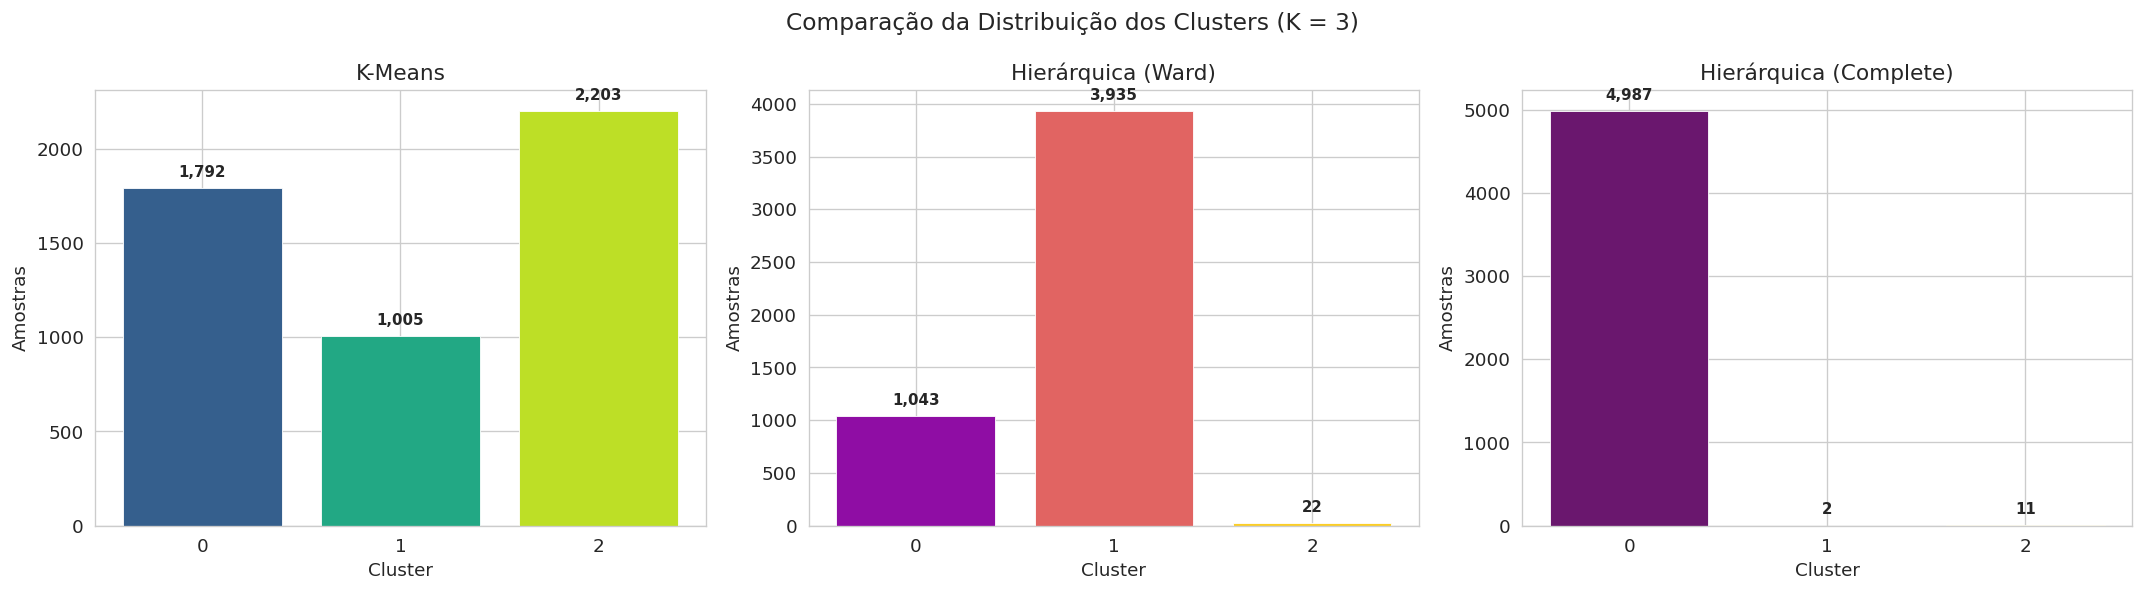

In [13]:
# Para comparar K-means com hierárquica na mesma amostra,
# obtemos os labels do K-means para a amostra utilizada
labels_kmeans_sample = labels_kmeans[sample_indices]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [
    ('K-Means', labels_kmeans_sample),
    ('Hierárquica (Ward)', labels_ward),
    ('Hierárquica (Complete)', labels_complete)
]

colormaps = [plt.cm.viridis, plt.cm.plasma, plt.cm.inferno]

for ax, (name, labels), cmap in zip(axes, methods, colormaps):
    unique_labels, label_counts = np.unique(labels, return_counts=True)
    colors = cmap(np.linspace(0.3, 0.9, len(unique_labels)))

    bars = ax.bar(unique_labels, label_counts, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Cluster', fontsize=11)
    ax.set_ylabel('Amostras', fontsize=11)
    ax.set_title(name, fontsize=13)
    ax.set_xticks(unique_labels)

    for bar, count in zip(bars, label_counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(label_counts) * 0.02,
                f'{count:,}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle(f'Comparação da Distribuição dos Clusters (K = {best_k})', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
# Tabela resumo comparativa
print('=== TABELA RESUMO ===')
print(f'\nNúmero de clusters (K): {best_k}')
print(f'Nota: K-Means utilizou o dataset completo ({len(X_scaled):,} amostras).')
print(f'Hierárquica utilizou amostra de {SAMPLE_SIZE:,} amostras.\n')

# Montar tabela
summary_data = {'Método': [], 'Cluster': [], 'Amostras': [], 'Proporção (%)': []}

# K-Means (dataset completo)
for cluster, count in zip(*np.unique(labels_kmeans, return_counts=True)):
    summary_data['Método'].append('K-Means')
    summary_data['Cluster'].append(cluster)
    summary_data['Amostras'].append(count)
    summary_data['Proporção (%)'].append(round(count / len(labels_kmeans) * 100, 1))

# Hierárquica Ward (amostra)
for cluster, count in zip(unique_w, counts_w):
    summary_data['Método'].append('Hierárq. Ward')
    summary_data['Cluster'].append(cluster)
    summary_data['Amostras'].append(count)
    summary_data['Proporção (%)'].append(round(count / len(labels_ward) * 100, 1))

# Hierárquica Complete (amostra)
for cluster, count in zip(unique_c, counts_c):
    summary_data['Método'].append('Hierárq. Complete')
    summary_data['Cluster'].append(cluster)
    summary_data['Amostras'].append(count)
    summary_data['Proporção (%)'].append(round(count / len(labels_complete) * 100, 1))

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False))

=== TABELA RESUMO ===

Número de clusters (K): 3
Nota: K-Means utilizou o dataset completo (101,763 amostras).
Hierárquica utilizou amostra de 5,000 amostras.

           Método  Cluster  Amostras  Proporção (%)
          K-Means        0     35446           34.8
          K-Means        1     20957           20.6
          K-Means        2     45360           44.6
    Hierárq. Ward        0      1043           20.9
    Hierárq. Ward        1      3935           78.7
    Hierárq. Ward        2        22            0.4
Hierárq. Complete        0      4987           99.7
Hierárq. Complete        1         2            0.0
Hierárq. Complete        2        11            0.2


## 4.7 — Discussão dos Resultados

### Método do Cotovelo

O método do cotovelo identificou o melhor valor de K observando o ponto onde a redução marginal da inércia diminui significativamente. A escolha desse K representa um equilíbrio entre:
- **Poucos clusters:** Alta inércia, pouca granularidade
- **Muitos clusters:** Baixa inércia, mas overfitting e clusters pouco interpretáveis

### K-Means vs Clusterização Hierárquica

**K-Means:**
- Tende a produzir clusters de **tamanhos mais equilibrados** devido à sua otimização baseada em centroides
- Assume clusters esféricos e de variância similar
- Escalável — conseguiu processar todo o dataset (~101k amostras)

**Hierárquica (Ward):**
- Similar ao K-Means na tendência de produzir clusters compactos e de tamanhos similares
- O critério de minimização da variância favorece fusões que mantêm a coesão intra-cluster
- Produz um dendrograma que revela a **estrutura hierárquica** dos dados

**Hierárquica (Complete):**
- Utiliza a distância máxima entre pontos, tornando-o mais **conservador** nas fusões
- Tende a produzir clusters com **diâmetros menores**
- Pode resultar em clusters de tamanhos mais **desiguais** comparado ao Ward
- Mais robusto a outliers que o linkage single

### Diferenças entre os Linkages

As diferenças entre Ward e Complete refletem seus critérios distintos:
- **Ward** prioriza a homogeneidade global (variância), resultando em clusters mais **regulares**
- **Complete** prioriza a distância máxima, resultando em clusters mais **compactos** mas potencialmente **desbalanceados**

### Interpretação Clínica

Os clusters identificados podem representar **perfis de pacientes** com padrões distintos de:
- Frequência de internações e emergências
- Complexidade clínica (número de diagnósticos e medicações)
- Tempo de hospitalização
- Tipo de alta hospitalar

Essa segmentação pode auxiliar na identificação de **grupos de risco** e na personalização de intervenções clínicas.

### Limitações

- A clusterização hierárquica foi aplicada em uma **amostra** do dataset devido à complexidade computacional O(n²), o que pode não capturar todos os padrões presentes nos dados completos
- O método do cotovelo pode ser subjetivo na identificação do ponto ideal
- K-Means assume clusters esféricos, o que pode não refletir a estrutura real dos dados clínicos

## 4.8 — Conclusão

Nesta questão, aplicamos técnicas de aprendizado não supervisionado ao dataset de diabetes:

1. **K-Means com Método do Cotovelo:** Identificamos o número ideal de clusters e segmentamos todo o dataset
2. **Clusterização Hierárquica:** Aplicamos dois métodos de linkage (Ward e Complete) com dendrogramas informativos

**Principais achados:**
- O K-Means produziu clusters com distribuição de tamanhos relativamente equilibrada
- O linkage Ward gerou clusters mais similares ao K-Means em termos de distribuição
- O linkage Complete revelou uma estrutura diferente, com clusters potencialmente mais compactos mas de tamanhos mais desiguais
- Os dendrogramas permitiram visualizar a estrutura hierárquica dos dados e validar a escolha de K

Os resultados demonstram que existem **perfis distintos de pacientes** no dataset, que podem ser explorados para estratégias de acompanhamento e prevenção de readmissões hospitalares.

**=== QUESTÃO 4 CONCLUÍDA ===